# Part 1e: Weight Initialization Strategies
**Author:** Kalhar Mayurbhai Patel (019140511)

Different activation functions work best with specific initializers:
- **Glorot/Xavier** → sigmoid, tanh, softmax
- **He** → ReLU and variants
- **LeCun** → SELU
We test each combination in TF and PyTorch.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=2000, n_features=20, n_informative=12, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## TensorFlow: Initialization Comparison

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TF ReLU + He Normal: Val Acc = 0.9333
TF ReLU + Glorot: Val Acc = 0.9533
TF ReLU + Zeros (bad): Val Acc = 0.4917
TF Tanh + Glorot: Val Acc = 0.9383
TF SELU + LeCun: Val Acc = 0.9467


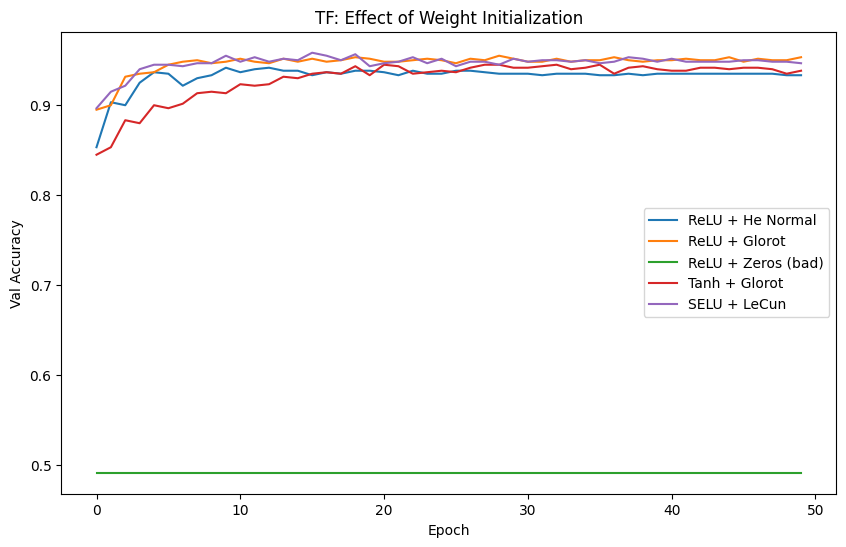

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

configs = [
    ('ReLU + He Normal', 'relu', 'he_normal'),
    ('ReLU + Glorot', 'relu', 'glorot_uniform'),
    ('ReLU + Zeros (bad)', 'relu', 'zeros'),
    ('Tanh + Glorot', 'tanh', 'glorot_uniform'),
    ('SELU + LeCun', 'selu', 'lecun_normal'),
]

results_tf = {}
for label, act, init in configs:
    m = Sequential([
        layers.Dense(128, activation=act, kernel_initializer=init, input_shape=(20,)),
        layers.Dense(64, activation=act, kernel_initializer=init),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train, y_train, epochs=50, batch_size=32,
              validation_data=(X_test, y_test), verbose=0)
    results_tf[label] = h.history['val_accuracy']
    print(f"TF {label}: Val Acc = {h.history['val_accuracy'][-1]:.4f}")

plt.figure(figsize=(10, 6))
for k, v in results_tf.items(): plt.plot(v, label=k)
plt.title('TF: Effect of Weight Initialization'); plt.xlabel('Epoch')
plt.ylabel('Val Accuracy'); plt.legend(); plt.show()

## PyTorch: Initialization Comparison

PT ReLU + He: Final Acc=0.9400
PT ReLU + Glorot: Final Acc=0.9417
PT ReLU + Zeros: Final Acc=0.4917
PT Tanh + Glorot: Final Acc=0.9383
PT SELU + LeCun: Final Acc=0.9450


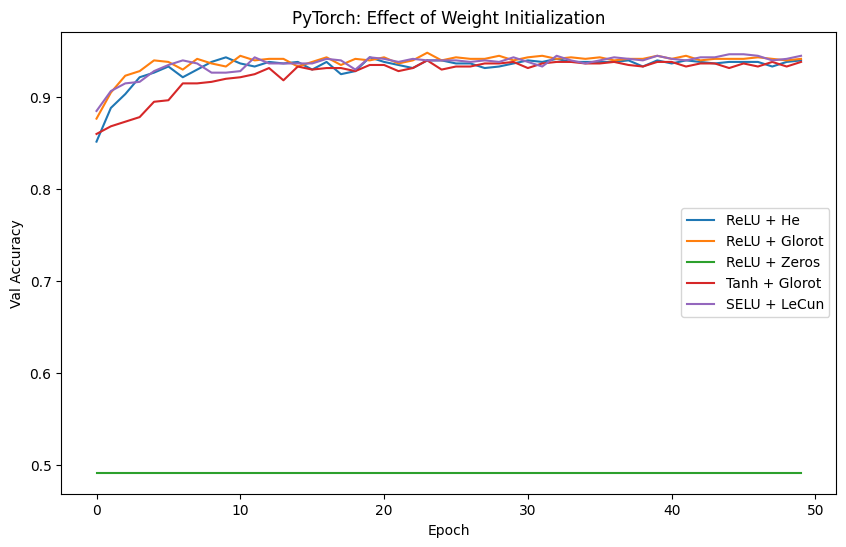

In [3]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dl = DataLoader(TensorDataset(torch.FloatTensor(X_train).to(device),
    torch.FloatTensor(y_train).unsqueeze(1).to(device)), batch_size=32, shuffle=True)
X_te = torch.FloatTensor(X_test).to(device)
y_te = torch.FloatTensor(y_test).unsqueeze(1).to(device)

def init_weights(m, method):
    if isinstance(m, nn.Linear):
        if method == 'he': nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        elif method == 'glorot': nn.init.xavier_uniform_(m.weight)
        elif method == 'lecun': nn.init.kaiming_normal_(m.weight, nonlinearity='linear')
        elif method == 'zeros': nn.init.zeros_(m.weight)
        nn.init.zeros_(m.bias)

configs_pt = [
    ('ReLU + He', nn.ReLU, 'he'),
    ('ReLU + Glorot', nn.ReLU, 'glorot'),
    ('ReLU + Zeros', nn.ReLU, 'zeros'),
    ('Tanh + Glorot', nn.Tanh, 'glorot'),
    ('SELU + LeCun', nn.SELU, 'lecun'),
]

results_pt = {}
for label, act_cls, init_m in configs_pt:
    torch.manual_seed(42)
    model = nn.Sequential(nn.Linear(20,128), act_cls(), nn.Linear(128,64),
                          act_cls(), nn.Linear(64,1), nn.Sigmoid()).to(device)
    model.apply(lambda m: init_weights(m, init_m))
    opt = torch.optim.Adam(model.parameters()); crit = nn.BCELoss()
    accs = []
    for ep in range(50):
        model.train()
        for xb, yb in dl:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            accs.append(((model(X_te)>0.5).float()==y_te).float().mean().item())
    results_pt[label] = accs
    print(f"PT {label}: Final Acc={accs[-1]:.4f}")

plt.figure(figsize=(10, 6))
for k, v in results_pt.items(): plt.plot(v, label=k)
plt.title('PyTorch: Effect of Weight Initialization')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend(); plt.show()

## When to Use What
| Initialization | Best With | Why |
|---|---|---|
| **He (Kaiming)** | ReLU, Leaky ReLU, PReLU | Accounts for ReLU zeroing half the inputs |
| **Glorot (Xavier)** | Sigmoid, Tanh, Softmax | Preserves variance for symmetric activations |
| **LeCun** | SELU | Designed for self-normalizing networks |
| **Zeros** | Never for weights! | Causes symmetry — all neurons learn the same thing |